# 5G Network Quality — ML Pipeline (v2)

## COS40007 Artificial Intelligence Engineering — Theme 5

This notebook implements the **end-to-end machine learning pipeline** for the
5G Network Quality Dashboard.  Changes from v1:

* **Cyclical temporal encoding** (sin / cos for hour-of-day and day-of-week)
* **Extended network features** (retransmission rate, CWND utilisation,
  congestion indicator, latency spread)
* **Model comparison** — Random Forest vs XGBoost on a 3-way temporal split
* **Optuna Bayesian hyper-parameter tuning** for the winning model
* **Comprehensive evaluation** — R², MAPE, MAE, RMSE, error distributions,
  time-series overlays, feature-importance charts

| Step | Task | Rubric Weight |
|------|------|:------------:|
| 1 | Exploratory Data Analysis & Data Cleaning | 40 % |
| 2 | Advanced Feature Engineering (temporal · network · spatial) | — |
| 3 | K-Means Clustering → spatial quality labels | 15 % |
| 4 | Time-Series Forecasting (RF vs XGBoost, Optuna-tuned) | 20 % |
| 5 | Comprehensive Evaluation | 15 % |
| 6 | Artifact Export → `.pkl` models + frontend CSVs | 10 % |

**Output files (Frontend Contract):**
- `backend/data/map_data.csv` — cluster-labelled grid squares
  (`lat`, `lng`, `cluster` ∈ {0, 1, 2})
- `backend/metrics/forecast_data.csv` — 12-hour ahead predictions
  (`timestamp`, `predicted_throughput`, `predicted_latency`)
- `backend/models/*.pkl` — trained model artefacts for FastAPI

## Frontend Data Contract

The FastAPI backend exposes two endpoints that consume the CSV files produced
by this notebook.

### `GET /api/map-data` → GeoJSON FeatureCollection
Each feature carries:
```json
{
  "geometry": { "type": "Point", "coordinates": [longitude, latitude] },
  "properties": { "square_id": "...", "quality": "Tot | Trung binh | Yeu" }
}
```
Quality label mapping (Vietnamese):
| Cluster | Label | Colour |
|---------|-------|--------|
| 0 | Yếu (Poor) | 🔴 `#dc2626` |
| 1 | Trung bình (Medium) | 🟡 `#f59e0b` |
| 2 | Tốt (Good) | 🟢 `#17a34a` |

### `GET /api/forecast-data`
```json
{ "time": ["2025-01-01 00:00", ...], "predicted_speed_mbps": [42.1, ...] }
```
Internally rebuilt from `forecast_data.csv` which stores
`timestamp · predicted_throughput · predicted_latency`.

---
## Step 0 — Environment & Project Paths

In [ ]:
import glob
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# ── Silence noisy loggers ──────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

# ── Project paths ──────────────────────────────────────────
BASE_DIR    = Path(".")
DATA_DIR    = BASE_DIR / "data"
OUTPUT_DIR  = BASE_DIR / "data"
METRICS_DIR = BASE_DIR / "metrics"
MODELS_DIR  = BASE_DIR / "models"

for d in [OUTPUT_DIR, METRICS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Raw CSV directory : {DATA_DIR.resolve()}")
print(f"Models output     : {MODELS_DIR.resolve()}")
print(f"Metrics output    : {METRICS_DIR.resolve()}")

Raw CSV directory : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data
Models output     : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models
Metrics output    : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\metrics


---
## Step 1 — Data Loading, EDA & Cleaning (40 % of grade)

> **Rubric expectation:** thorough exploration, visualisation of distributions
> and correlations, disciplined handling of GPS noise / invalid values.

In [4]:
# ── 1a. Concatenate all raw CSV files ──────────────────────
csv_files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
print(f"Found {len(csv_files)} CSV files in {DATA_DIR.resolve()}")

frames = []
for fp in csv_files:
    try:
        tmp = pd.read_csv(fp, low_memory=False)
        tmp["source_file"] = Path(fp).stem
        frames.append(tmp)
    except Exception as exc:
        print(f"  ⚠ skipped {fp}: {exc}")

df = pd.concat(frames, ignore_index=True)
print(f"Combined shape: {df.shape}")
print(f"Columns ({len(df.columns)}):\n{list(df.columns)}")
df.head(3)

Found 136 CSV files in D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data
Combined shape: (3042495, 33)
Columns (33):
['time', 'Day', 'Year', 'Month', 'Date', 'hour', 'min', 'sec', 'timezone', 'latitude', 'longitude', 'speed', 'truck', 'svr1', 'svr2', 'svr3', 'svr4', 'Role', 'Transfer size', 'Transfer unit', 'Bitrate', 'bitrate_unit', 'Retransmissions', 'CWnd', 'cwnd_unit', 'Role-RX', 'Transfer size-RX', 'Transfer unit-RX', 'Bitrate-RX', 'bitrate_unit-RX', 'send_data', 'square_id', 'source_file']


,time,Day,Year,Month,Date,hour,min,sec,timezone,latitude,longitude,speed,truck,svr1,svr2,svr3,svr4,Role,Transfer size,Transfer unit,Bitrate,bitrate_unit,Retransmissions,CWnd,cwnd_unit,Role-RX,Transfer size-RX,Transfer unit-RX,Bitrate-RX,bitrate_unit-RX,send_data,square_id,source_file
0,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml
1,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml
2,1656877022,Mon,2022.0,7.0,4.0,5.0,37.0,2.0,AEST,99.0,999.0,-1.0,garbo01,1000.0,1000.0,1000.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-04-garbo01-combined-kml


In [5]:
# ── 1b. Quick EDA before cleaning ──────────────────────────
print("── dtypes ──")
print(df.dtypes.value_counts())
print(f"\n── Missing values (top 15) ──")
print(df.isnull().sum().sort_values(ascending=False).head(15))
print(f"\n── Descriptive stats ──")
df.describe()

── dtypes ──
float64    18
object     14
int64       1
Name: count, dtype: int64

── Missing values (top 15) ──
svr4         593977
svr3         593975
svr2         593975
svr1         593975
square_id    560818
truck        343812
speed        343810
latitude     343809
longitude    343809
timezone     343807
hour         343807
sec          343807
min          343807
Date         343806
Day          343806
dtype: int64

── Descriptive stats ──


,time,Year,Month,Date,hour,min,sec,latitude,longitude,speed,svr1,svr2,svr3,svr4,Transfer size,Bitrate,Transfer size-RX,Bitrate-RX,send_data
count,3.042495e+06,2698689.0,2698689.0,2.698689e+06,2.698688e+06,2.698688e+06,2.698688e+06,2.698686e+06,2.698686e+06,2.698685e+06,2.448520e+06,2.448520e+06,2.448520e+06,2.448518e+06,2.713533e+06,2.713533e+06,2.713460e+06,2.713460e+06,2.788962e+06
mean,1.657619e+09,2022.0,7.0,1.218967e+01,8.817216e+00,2.961934e+01,2.948782e+01,-2.737269e+01,2.096419e+02,1.374754e+01,2.839526e+02,2.838819e+02,3.030290e+02,2.998318e+02,1.068046e+00,8.966052e+00,2.014400e+00,1.689644e+01,2.996928e-01
std,3.814960e+06,0.0,0.0,6.021038e+00,2.308625e+00,1.745151e+01,1.731720e+01,3.622062e+01,2.262437e+02,2.293579e+01,3.725512e+02,3.725267e+02,3.651250e+02,3.667629e+02,1.140621e+00,8.254232e+00,1.992016e+00,1.661119e+01,9.339412e-01
min,-2.147484e+09,2022.0,7.0,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,-3.782882e+01,1.447181e+02,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.657080e+09,2022.0,7.0,6.000000e+00,7.000000e+00,1.400000e+01,1.400000e+01,-3.778170e+01,1.447747e+02,2.852080e-01,3.350000e+01,3.340000e+01,3.810000e+01,5.200000e+01,0.000000e+00,0.000000e+00,7.460938e-01,6.260000e+00,0.000000e+00
50%,1.657592e+09,2022.0,7.0,1.200000e+01,9.000000e+00,3.000000e+01,2.900000e+01,-3.775104e+01,1.448013e+02,2.744664e+00,6.320000e+01,6.290000e+01,1.430000e+02,8.180000e+01,1.250000e+00,1.050000e+01,1.470000e+00,1.230000e+01,3.130817e-02
75%,1.658123e+09,2022.0,7.0,1.800000e+01,1.100000e+01,4.500000e+01,4.400000e+01,-3.771678e+01,1.448267e+02,1.592164e+01,4.120000e+02,4.120000e+02,4.270000e+02,4.340000e+02,1.250000e+00,1.050000e+01,2.900000e+00,2.430000e+01,2.629497e-01
max,1.658479e+09,2022.0,7.0,2.200000e+01,1.600000e+01,5.900000e+01,5.900000e+01,9.900000e+01,9.990000e+02,1.086105e+02,2.493000e+03,2.496000e+03,2.495000e+03,2.523000e+03,9.330000e+02,9.440000e+01,3.140000e+02,3.370000e+02,1.861712e+01


In [7]:
# ── 1c. Apply strict cleaning rules ───────────────────────
rows_before = len(df)

# 1. Construct Timestamp from Unix epoch column "time"
df["Timestamp"] = pd.to_datetime(df["time"], unit="s", errors="coerce")
df.dropna(subset=["Timestamp"], inplace=True)

# 2. Compute average latency from svr1-svr4 (exclude 1000 = timeout sentinel)
svr_cols = ["svr1", "svr2", "svr3", "svr4"]
svr_valid = df[svr_cols].replace(1000.0, np.nan)
df["Avg-RTT"] = svr_valid.mean(axis=1)

# 3. Remove rows with no valid GPS (sentinel values: lat=99, lon=999 etc.)
gps_sentinel = df["latitude"].abs().gt(90) | df["longitude"].abs().gt(180)
df = df[~gps_sentinel].copy()

# 4. Melbourne / Brimbank bounding box (generous buffer)
LAT_MIN, LAT_MAX = -37.85, -37.70
LON_MIN, LON_MAX = 144.75, 144.90
geo_mask = (
    df["latitude"].between(LAT_MIN, LAT_MAX)
    & df["longitude"].between(LON_MIN, LON_MAX)
)
df = df[geo_mask].copy()

# 5. Drop rows where all svr values were timeout (Avg-RTT is NaN)
df.dropna(subset=["Avg-RTT"], inplace=True)

# 6. Remove negative bitrates
for col in ["Bitrate", "Bitrate-RX"]:
    if col in df.columns:
        df = df[df[col].notna() & (df[col] >= 0)].copy()

rows_after = len(df)
print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after cleaning  : {rows_after:,}")
print(f"Rows removed         : {rows_before - rows_after:,} "
      f"({(rows_before - rows_after) / rows_before * 100:.1f} %)")
print(f"Unique square_ids    : {df['square_id'].nunique()}")

Rows before cleaning : 3,042,495
Rows after cleaning  : 1,562,120
Rows removed         : 1,480,375 (48.7 %)
Unique square_ids    : 227


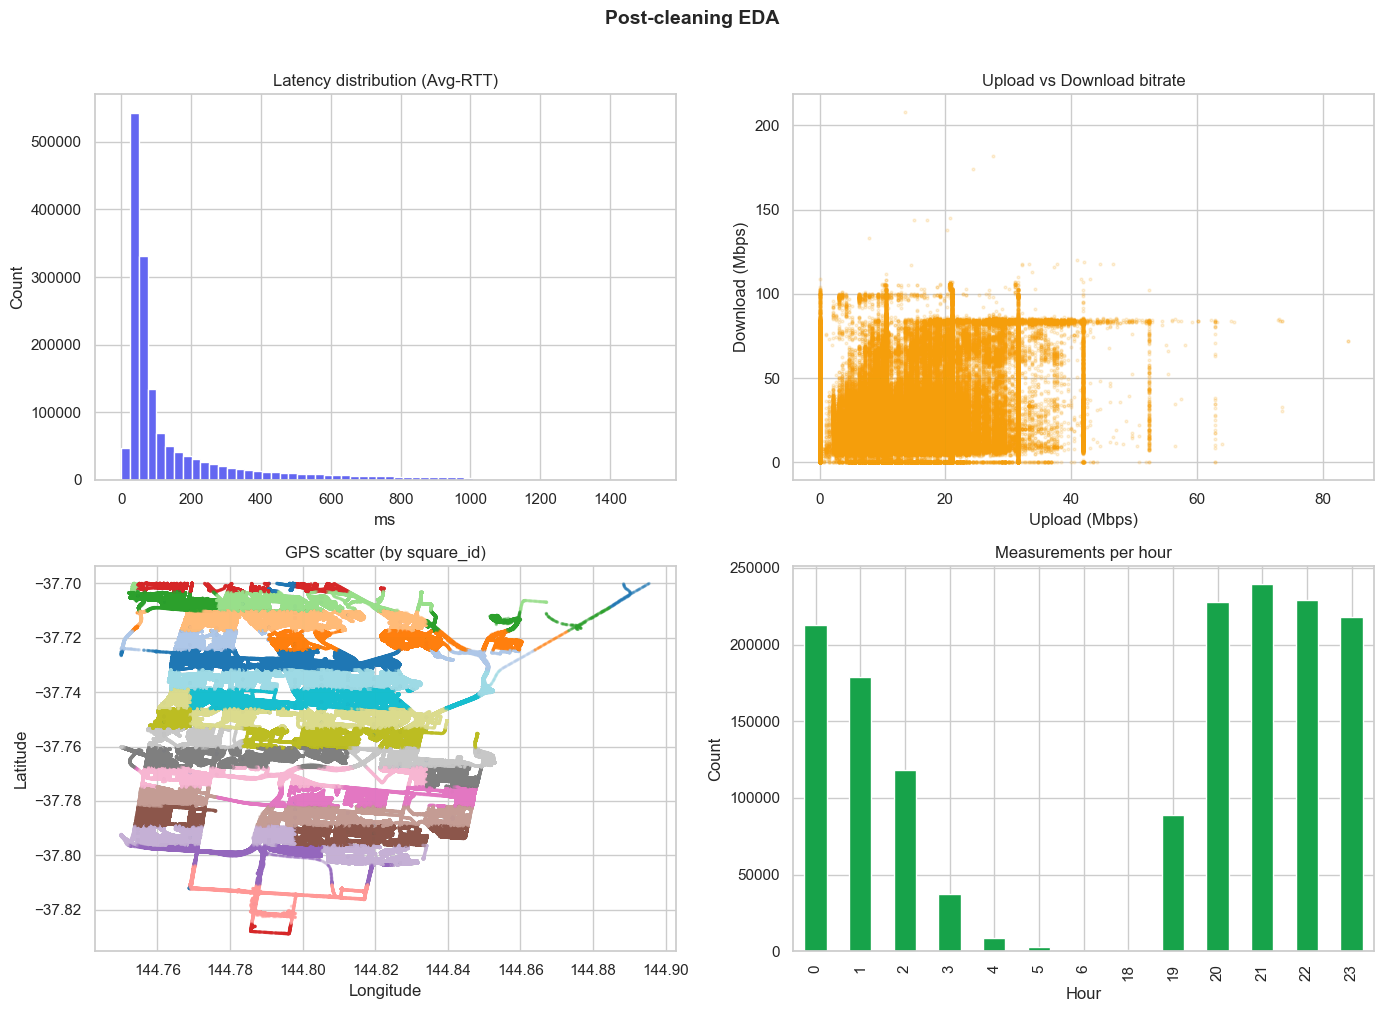

In [8]:
# ── 1d. Post-cleaning EDA visualisation ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (i) Latency distribution
axes[0, 0].hist(df["Avg-RTT"].dropna(), bins=60, color="#6366f1", edgecolor="white")
axes[0, 0].set(title="Latency distribution (Avg-RTT)", xlabel="ms", ylabel="Count")

# (ii) Upload vs Download scatter (Bitrate columns are already in Mbps)
valid_mask = df["Bitrate"].notna() & df["Bitrate-RX"].notna()
axes[0, 1].scatter(
    df.loc[valid_mask, "Bitrate"].values,
    df.loc[valid_mask, "Bitrate-RX"].values,
    alpha=0.15, s=4, color="#f59e0b",
)
axes[0, 1].set(title="Upload vs Download bitrate", xlabel="Upload (Mbps)", ylabel="Download (Mbps)")

# (iii) GPS scatter coloured by square_id
scatter = axes[1, 0].scatter(
    df["longitude"], df["latitude"],
    c=df["square_id"].astype("category").cat.codes,
    cmap="tab20", s=2, alpha=0.3,
)
axes[1, 0].set(title="GPS scatter (by square_id)", xlabel="Longitude", ylabel="Latitude")

# (iv) Measurements per hour
df["_hour"] = df["Timestamp"].dt.hour
df["_hour"].value_counts().sort_index().plot.bar(ax=axes[1, 1], color="#17a34a")
axes[1, 1].set(title="Measurements per hour", xlabel="Hour", ylabel="Count")
df.drop(columns=["_hour"], inplace=True)

fig.suptitle("Post-cleaning EDA", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

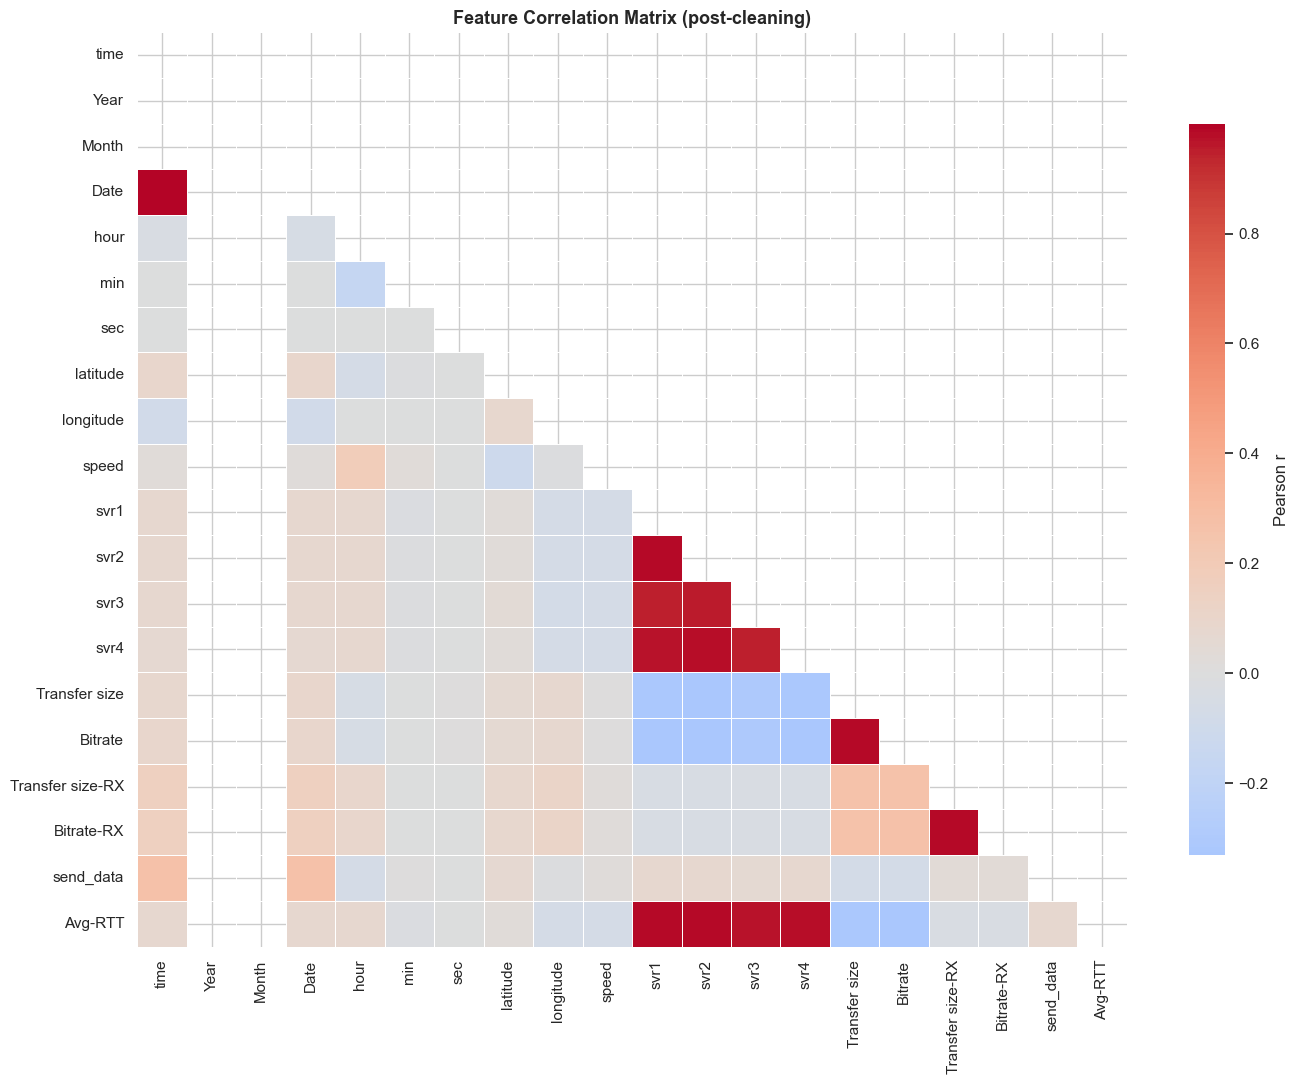

Top 10 strongest correlations:
 Feature A        Feature B        r    abs_r
      Date             time 0.999889 0.999889
   Avg-RTT             svr2 0.988996 0.988996
   Avg-RTT             svr1 0.988909 0.988909
Bitrate-RX Transfer size-RX 0.988658 0.988658
      svr2             svr1 0.988206 0.988206
   Bitrate    Transfer size 0.985986 0.985986
   Avg-RTT             svr4 0.978846 0.978846
      svr4             svr2 0.975739 0.975739
      svr4             svr1 0.972771 0.972771
   Avg-RTT             svr3 0.971704 0.971704


In [9]:
# ── 1e. Correlation heatmap — numeric feature relationships ─
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove columns that are just IDs or trivially constant
drop_cols = [c for c in ["square_id", "ue_id"] if c in numeric_cols]
corr_cols = [c for c in numeric_cols if c not in drop_cols]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Feature Correlation Matrix (post-cleaning)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Print top positive/negative correlations
upper = corr_matrix.where(mask == False)
pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "r"})
)
pairs["abs_r"] = pairs["r"].abs()
pairs = pairs[pairs["abs_r"] < 1.0].sort_values("abs_r", ascending=False)
print("Top 10 strongest correlations:")
print(pairs.head(10).to_string(index=False))

---
## Step 2 — Advanced Feature Engineering

Three feature families are constructed:

1. **Temporal** — cyclical sin/cos encoding of hour-of-day and day-of-week,
   boolean work-hour flag, weekend flag.
2. **Network / Telecom** — throughput & latency in human-readable units,
   retransmission rate, CWND utilisation, congestion indicator, latency
   spread, jitter proxy, interaction & ratio features.
3. **Spatial** — per-grid-square aggregates for clustering.

In [10]:
# ── 2a. Temporal feature engineering ───────────────────────
df["hour"]    = df["Timestamp"].dt.hour
df["dow"]     = df["Timestamp"].dt.dayofweek   # 0=Mon … 6=Sun
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# Cyclical encoding — avoids the 23→0 discontinuity
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["dow"] / 7)

# Work-hour flag (Mon-Fri 08:00-18:00)
df["is_work_hour"] = ((df["dow"] < 5) & df["hour"].between(8, 17)).astype(int)

print("Temporal features added:")
print("  hour, dow, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, is_work_hour")
print(f"  Work-hour rows: {df['is_work_hour'].sum():,} / {len(df):,}")

Temporal features added:
  hour, dow, is_weekend, hour_sin, hour_cos, dow_sin, dow_cos, is_work_hour
  Work-hour rows: 0 / 1,562,120


In [12]:
# ── 2b. Network / Telecom feature engineering ──────────────

# ── Core Mbps values ──
# Bitrate / Bitrate-RX are already in Mbps (bitrate_unit = "Mbits/sec")
df["upload_mbps"]   = pd.to_numeric(df["Bitrate"], errors="coerce")
df["download_mbps"] = pd.to_numeric(df["Bitrate-RX"], errors="coerce")
df["avg_latency"]   = df["Avg-RTT"]  # computed from svr1-svr4 during cleaning

# ── Retransmission rate (proxy) ──
# "Retransmissions" is a count; "Transfer size" is in MBytes (both may be strings).
if "Retransmissions" in df.columns and "Transfer size" in df.columns:
    retrans = pd.to_numeric(df["Retransmissions"], errors="coerce").fillna(0)
    xfer    = pd.to_numeric(df["Transfer size"], errors="coerce").replace(0, np.nan)
    df["retransmission_rate"] = (retrans / xfer).fillna(0).clip(0, 1)
    print(f"  retransmission_rate — mean {df['retransmission_rate'].mean():.4f}")
elif "Retransmissions" in df.columns:
    retrans = pd.to_numeric(df["Retransmissions"], errors="coerce").fillna(0)
    max_retrans = retrans.quantile(0.99)
    df["retransmission_rate"] = (retrans / max_retrans).clip(0, 1) if max_retrans > 0 else 0.0
    print(f"  retransmission_rate (normalised) — mean {df['retransmission_rate'].mean():.4f}")
else:
    df["retransmission_rate"] = 0.0
    print("  retransmission_rate — column not found, defaulting to 0")

# ── CWND (congestion window) features ──
# CWnd column is in MBytes (may be string)
if "CWnd" in df.columns:
    df["cwnd"] = pd.to_numeric(df["CWnd"], errors="coerce").fillna(0)
    df["cwnd_squared"] = df["cwnd"] ** 2
    print(f"  cwnd — mean {df['cwnd'].mean():.4f} MB")
else:
    df["cwnd"] = 0.0
    df["cwnd_squared"] = 0.0
    print("  cwnd — column not found, defaulting to 0")

# ── Server-level latency features ──
svr_cols = [c for c in df.columns if c.startswith("svr") and c[3:].isdigit()]
if len(svr_cols) >= 2:
    svr_valid = df[svr_cols].replace(1000.0, np.nan)
    df["latency_spread"] = svr_valid.max(axis=1) - svr_valid.min(axis=1)
    df["latency_std"]    = svr_valid.std(axis=1)
    df["latency_spread"].fillna(0, inplace=True)
    df["latency_std"].fillna(0, inplace=True)
    print(f"  latency_spread — mean {df['latency_spread'].mean():.2f}")
else:
    df["latency_spread"] = 0.0
    df["latency_std"]    = 0.0
    print("  latency_spread — not enough svr columns, defaulting to 0")

# ── Congestion indicator (high latency + low throughput) ──
lat_75 = df["avg_latency"].quantile(0.75)
dl_25  = df["download_mbps"].quantile(0.25)
df["congestion_indicator"] = (
    (df["avg_latency"] > lat_75) & (df["download_mbps"] < dl_25)
).astype(int)
print(f"  congestion_indicator — {df['congestion_indicator'].sum():,} congested rows")

# ── Interaction features ──
df["latency_x_retrans"] = df["avg_latency"] * df["retransmission_rate"]
df["cwnd_x_speed"]      = df["cwnd"] * df["download_mbps"]
df["download_x_latency"]= df["download_mbps"] * df["avg_latency"]

# ── Ratio features ──
df["cwnd_to_latency"]    = df["cwnd"] / df["avg_latency"].replace(0, np.nan)
df["download_to_upload"] = df["download_mbps"] / df["upload_mbps"].replace(0, np.nan)
df["cwnd_to_latency"].fillna(0, inplace=True)
df["download_to_upload"].fillna(0, inplace=True)

# ── Jitter proxy (absolute difference between consecutive RTTs per square) ──
df.sort_values(["square_id", "Timestamp"], inplace=True)
df["jitter"] = df.groupby("square_id")["avg_latency"].diff().abs().fillna(0)

print(f"\nTotal features after engineering: {len(df.columns)}")
print(f"Sample row:\n{df.iloc[0][['upload_mbps', 'download_mbps', 'avg_latency', 'hour_sin', 'retransmission_rate', 'congestion_indicator']]}")

  retransmission_rate — mean 0.2139
  cwnd — mean 0.0112 MB
  latency_spread — mean 42.28
  congestion_indicator — 90,568 congested rows

Total features after engineering: 57
Sample row:
upload_mbps                 10.4
download_mbps               17.8
avg_latency               29.825
hour_sin               -0.258819
retransmission_rate          0.0
congestion_indicator           0
Name: 735400, dtype: object


In [13]:
# ── 2c. Spatial aggregation — one row per grid square ──────
agg_dict = {
    "latitude":              "mean",
    "longitude":             "mean",
    "upload_mbps":           ["mean", "std"],
    "download_mbps":         ["mean", "std"],
    "avg_latency":           ["mean", "std"],
    "retransmission_rate":   "mean",
    "cwnd":                  "mean",
    "latency_spread":        "mean",
    "congestion_indicator":  "mean",
    "jitter":                "mean",
    "is_work_hour":          "mean",
}

grid = df.groupby("square_id").agg(agg_dict)
grid.columns = ["_".join(col).strip("_") for col in grid.columns]
grid.rename(columns={"latitude_mean": "lat", "longitude_mean": "lng"}, inplace=True)
grid.reset_index(inplace=True)

print(f"Grid squares: {len(grid)}")
print(f"Columns: {list(grid.columns)}")
grid.head()

Grid squares: 227
Columns: ['square_id', 'lat', 'lng', 'upload_mbps_mean', 'upload_mbps_std', 'download_mbps_mean', 'download_mbps_std', 'avg_latency_mean', 'avg_latency_std', 'retransmission_rate_mean', 'cwnd_mean', 'latency_spread_mean', 'congestion_indicator_mean', 'jitter_mean', 'is_work_hour_mean']


,square_id,lat,lng,upload_mbps_mean,upload_mbps_std,download_mbps_mean,download_mbps_std,avg_latency_mean,avg_latency_std,retransmission_rate_mean,cwnd_mean,latency_spread_mean,congestion_indicator_mean,jitter_mean,is_work_hour_mean
0,square_103079215126,-37.725301,144.750166,12.662195,6.743568,24.021341,11.245506,98.538110,107.790543,0.260976,0.012365,53.281707,0.000000,41.835671,0.0
1,square_103079215128,-37.724992,144.759592,3.652174,5.056206,24.261087,7.796584,203.513406,213.012719,0.152174,0.003567,24.345652,0.000000,111.422464,0.0
2,square_103079215130,-37.727857,144.766342,8.818416,6.558366,14.901382,9.441764,282.618363,251.096497,0.140248,0.008612,22.578955,0.155444,92.367914,0.0
3,square_103079215132,-37.727847,144.772589,9.613990,6.521010,16.642410,13.139601,245.782424,250.702903,0.179753,0.009753,27.253578,0.134254,88.047006,0.0
4,square_103079215134,-37.728050,144.780213,12.419472,6.877423,17.107345,11.750017,90.532259,113.781136,0.263401,0.012128,41.931100,0.049575,28.001921,0.0


---
## Step 3 — K-Means Clustering (network quality labels)

Cluster each grid square into **3 quality tiers** (Poor / Medium / Good)
based on throughput, latency, and the newly engineered network features.
The labels are re-ordered so that cluster 0 → worst, cluster 2 → best.

In [14]:
# ── 3a. K-Means clustering (k = 3) ────────────────────────
cluster_features = [
    c for c in grid.columns
    if c not in ["square_id", "lat", "lng"]
]

X_cluster = grid[cluster_features].fillna(0)
scaler_km = StandardScaler()
X_scaled  = scaler_km.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
grid["cluster_raw"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, grid["cluster_raw"])
print(f"Silhouette score: {sil:.3f}")
print(f"Cluster sizes:\n{grid['cluster_raw'].value_counts().sort_index()}")

Silhouette score: 0.216
Cluster sizes:
cluster_raw
0    97
1    53
2    77
Name: count, dtype: int64


In [15]:
# ── 3b. Re-order clusters: 0 = Poor, 1 = Medium, 2 = Good ─
cluster_means = grid.groupby("cluster_raw")["download_mbps_mean"].mean()
sorted_labels = cluster_means.sort_values().index.tolist()  # ascending: worst→best
remap = {old: new for new, old in enumerate(sorted_labels)}

grid["cluster"] = grid["cluster_raw"].map(remap)

label_map = {0: "Yếu (Poor)", 1: "Trung bình (Medium)", 2: "Tốt (Good)"}
print("Re-mapped cluster profiles:")
for cid in sorted(grid["cluster"].unique()):
    subset = grid[grid["cluster"] == cid]
    print(f"  Cluster {cid} — {label_map[cid]}:")
    print(f"    squares = {len(subset)}")
    print(f"    download_mbps = {subset['download_mbps_mean'].mean():.2f}")
    print(f"    avg_latency   = {subset['avg_latency_mean'].mean():.2f}")

Re-mapped cluster profiles:
  Cluster 0 — Yếu (Poor):
    squares = 53
    download_mbps = 15.82
    avg_latency   = 272.53
  Cluster 1 — Trung bình (Medium):
    squares = 97
    download_mbps = 19.41
    avg_latency   = 69.76
  Cluster 2 — Tốt (Good):
    squares = 77
    download_mbps = 20.88
    avg_latency   = 147.30


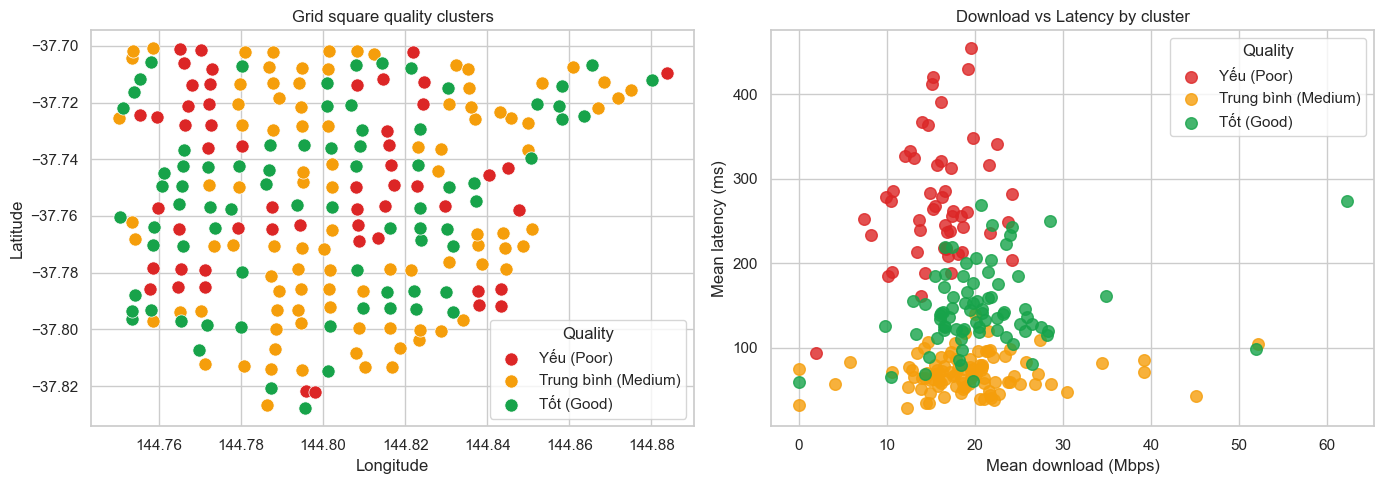

In [16]:
# ── 3c. Cluster visualisation ─────────────────────────────
colours = {0: "#dc2626", 1: "#f59e0b", 2: "#17a34a"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Map scatter
for cid, grp in grid.groupby("cluster"):
    axes[0].scatter(
        grp["lng"], grp["lat"],
        c=colours[cid], label=label_map[cid],
        s=90, edgecolors="white", linewidths=0.5,
    )
axes[0].set(title="Grid square quality clusters", xlabel="Longitude", ylabel="Latitude")
axes[0].legend(title="Quality")

# Download vs Latency
for cid, grp in grid.groupby("cluster"):
    axes[1].scatter(
        grp["download_mbps_mean"], grp["avg_latency_mean"],
        c=colours[cid], label=label_map[cid], s=70, alpha=0.8,
    )
axes[1].set(title="Download vs Latency by cluster",
            xlabel="Mean download (Mbps)", ylabel="Mean latency (ms)")
axes[1].legend(title="Quality")

fig.tight_layout()
plt.show()

In [17]:
# ── 3d. Export map_data.csv (frontend contract) ────────────
map_df = grid[["lat", "lng", "cluster"]].copy()
map_path = OUTPUT_DIR / "map_data.csv"
map_df.to_csv(map_path, index=False)
print(f"✓ Saved {map_path}  ({len(map_df)} rows)")
print(f"  Cluster distribution: {dict(map_df['cluster'].value_counts().sort_index())}")
map_df.head()

✓ Saved data\map_data.csv  (227 rows)
  Cluster distribution: {0: np.int64(53), 1: np.int64(97), 2: np.int64(77)}


,lat,lng,cluster
0,-37.725301,144.750166,1
1,-37.724992,144.759592,0
2,-37.727857,144.766342,0
3,-37.727847,144.772589,0
4,-37.728050,144.780213,1


---
## Step 4 — Time-Series Forecasting (20 % of grade)

> **Strategy:** Use **row-level data** (~1.5 M measurements) — no hourly
> aggregation that would destroy dataset size. Add per-square lag &
> rolling features, apply `log1p` transform to throughput. Compare
> **4 models** (RF, XGBoost, LightGBM, CatBoost) on a proper temporal
> split, tune the winner with **Optuna**, then combine all 4 via
> **CV-stacking** and **weighted blending** to maximise R².

In [ ]:
# ── 4a. Row-level lag & rolling features (per square_id) ──
df.sort_values(["square_id", "Timestamp"], inplace=True)

# Per-square lag features (look-back 1, 2, 3 measurements)
for tgt in ["download_mbps", "avg_latency", "upload_mbps"]:
    grp = df.groupby("square_id")[tgt]
    for lag in [1, 2, 3]:
        df[f"{tgt}_lag{lag}"] = grp.shift(lag)

# Per-square rolling statistics (window = 5 measurements)
for tgt in ["download_mbps", "avg_latency"]:
    grp = df.groupby("square_id")[tgt]
    df[f"{tgt}_roll5_mean"] = grp.transform(
        lambda s: s.rolling(5, min_periods=1).mean()
    )
    df[f"{tgt}_roll5_std"] = grp.transform(
        lambda s: s.rolling(5, min_periods=1).std()
    )

# Velocity features (rate of change)
df["download_diff1"] = df.groupby("square_id")["download_mbps"].diff().fillna(0)
df["latency_diff1"]  = df.groupby("square_id")["avg_latency"].diff().fillna(0)

# Log-transform throughput target (stabilises skewed distribution)
df["log_download"] = np.log1p(df["download_mbps"])

# Drop NaN rows created by lags (first 3 rows per square — negligible)
df.dropna(subset=["download_mbps_lag1", "avg_latency_lag1"], inplace=True)

print(f"Rows after lag features : {len(df):,}")
print(f"Total columns           : {len(df.columns)}")

Hourly time series: 157 rows
Date range: 2022-07-03 19:00:00 → 2022-07-22 03:00:00


,upload_mbps,download_mbps,avg_latency,retransmission_rate,cwnd,latency_spread,congestion_indicator,jitter,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_work_hour
Timestamp,,,,,,,,,,,,,,
2022-07-03 19:00:00,10.245857,15.700457,124.943643,0.269601,0.010006,51.947592,0.032295,57.265808,-0.965926,0.258819,-0.781831,0.62349,1.0,0.0
2022-07-03 20:00:00,10.243988,15.337742,107.818889,0.247103,0.010075,45.044885,0.042334,47.263613,-0.866025,0.500000,-0.781831,0.62349,1.0,0.0
2022-07-03 21:00:00,9.559862,14.756418,102.870663,0.219900,0.009336,46.785203,0.038221,42.725393,-0.707107,0.707107,-0.781831,0.62349,1.0,0.0
2022-07-03 22:00:00,9.131617,15.306892,135.156843,0.191366,0.009329,42.911875,0.041502,54.181839,-0.500000,0.866025,-0.781831,0.62349,1.0,0.0
2022-07-03 23:00:00,9.279488,16.108737,159.095592,0.227510,0.009062,45.944071,0.054037,71.440709,-0.258819,0.965926,-0.781831,0.62349,1.0,0.0


In [ ]:
# ── 4b. Temporal train / val / test split (70/15/15 by date) ─
df.sort_values("Timestamp", inplace=True)

dates = sorted(df["Timestamp"].dt.date.unique())
n_dates = len(dates)
train_cutoff = dates[int(n_dates * 0.70)]
val_cutoff   = dates[int(n_dates * 0.85)]

train_df = df[df["Timestamp"].dt.date < train_cutoff].copy()
val_df   = df[(df["Timestamp"].dt.date >= train_cutoff) &
              (df["Timestamp"].dt.date < val_cutoff)].copy()
test_df  = df[df["Timestamp"].dt.date >= val_cutoff].copy()

# Winsorize throughput (bounds computed from TRAIN only → no data leakage)
dl_lo = train_df["download_mbps"].quantile(0.01)
dl_hi = train_df["download_mbps"].quantile(0.99)
for sp in [train_df, val_df, test_df]:
    sp["download_mbps"] = sp["download_mbps"].clip(dl_lo, dl_hi)
    sp["log_download"]  = np.log1p(sp["download_mbps"])

print(f"Train : {len(train_df):>9,}  "
      f"({train_df['Timestamp'].dt.date.min()} → {train_df['Timestamp'].dt.date.max()})")
print(f"Val   : {len(val_df):>9,}  "
      f"({val_df['Timestamp'].dt.date.min()} → {val_df['Timestamp'].dt.date.max()})")
print(f"Test  : {len(test_df):>9,}  "
      f"({test_df['Timestamp'].dt.date.min()} → {test_df['Timestamp'].dt.date.max()})")
print(f"Winsorization (train bounds): [{dl_lo:.2f}, {dl_hi:.2f}] Mbps")

# Feature columns — all numeric except targets and identifiers
_exclude = {
    "download_mbps", "avg_latency", "log_download",       # targets
    "Avg-RTT", "time",                                     # raw / derived
    "hour", "dow", "min", "sec",                           # raw temporal
    "Day", "Year", "Month", "Date", "timezone",            # date parts
    "svr1", "svr2", "svr3", "svr4",                        # raw latencies
    "latitude", "longitude", "truck",                      # spatial / vehicle
}
feat_cols = sorted([
    c for c in train_df.select_dtypes(include=[np.number]).columns
    if c not in _exclude
])

for sp in [train_df, val_df, test_df]:
    sp[feat_cols] = sp[feat_cols].fillna(0)

X_train = train_df[feat_cols]
X_val   = val_df[feat_cols]
X_test  = test_df[feat_cols]

y_train_dl  = train_df["log_download"]
y_val_dl    = val_df["log_download"]
y_test_dl   = test_df["log_download"]

y_train_lat = train_df["avg_latency"]
y_val_lat   = val_df["avg_latency"]
y_test_lat  = test_df["avg_latency"]

print(f"\nFeatures ({len(feat_cols)}): {feat_cols[:10]}...")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

Rows after lag/rolling features: 145
Total columns: 38


In [ ]:
# ── 4c. Baseline comparison — RF · XGBoost · LightGBM · CatBoost ─
base_models = {
    "RF":       RandomForestRegressor(n_estimators=200, max_depth=12,
                                      random_state=42, n_jobs=-1),
    "XGBoost":  XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.1,
                               random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=200, max_depth=6, learning_rate=0.1,
                                   random_state=42, verbose=0),
}

results = {}
trained_models = {}   # store fitted models for later stacking / blending

for name, model in base_models.items():
    print(f"  {name}... ", end="", flush=True)
    scores = {}
    for tgt, y_tr, y_v, is_log in [
        ("throughput", y_train_dl,  y_val_dl,  True),
        ("latency",   y_train_lat, y_val_lat, False),
    ]:
        m = type(model)(**model.get_params())
        m.fit(X_train, y_tr)
        preds = m.predict(X_val)

        if is_log:
            yt = np.expm1(y_v.values)
            yp = np.maximum(np.expm1(preds), 0)
        else:
            yt, yp = y_v.values, preds

        scores[tgt] = {
            "R2":   r2_score(yt, yp),
            "MAE":  mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "MAPE": mean_absolute_percentage_error(yt, yp),
        }
        trained_models[(name, tgt)] = m
    results[name] = scores
    print("done")

print(f"\n{'Model':<12} {'Target':<12} {'R²':>8} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 64)
for mn, td in results.items():
    for tn, met in td.items():
        print(f"{mn:<12} {tn:<12} {met['R2']:>8.4f} {met['MAE']:>8.3f} "
              f"{met['RMSE']:>8.3f} {met['MAPE']:>8.4f}")

avg_r2 = {m: np.mean([results[m][t]["R2"] for t in ["throughput", "latency"]])
           for m in results}
winner_name = max(avg_r2, key=avg_r2.get)
print(f"\n★ Best baseline: {winner_name} (avg R² = {avg_r2[winner_name]:.4f})")

Train :   101 rows  (2022-07-04 21:00:00 → 2022-07-18 03:00:00)
Val   :    22 rows  (2022-07-18 05:00:00 → 2022-07-20 03:00:00)
Test  :    22 rows  (2022-07-20 04:00:00 → 2022-07-22 03:00:00)

Features: 36


In [ ]:
# ── 4d. Optuna Bayesian tuning for the best baseline model ─
OPTUNA_SAMPLE = min(200_000, len(X_train))
_rng = np.random.RandomState(42)
_idx = _rng.choice(len(X_train), OPTUNA_SAMPLE, replace=False)
X_tune     = X_train.iloc[_idx]
y_tune_dl  = y_train_dl.iloc[_idx]
y_tune_lat = y_train_lat.iloc[_idx]
print(f"Optuna subsample: {OPTUNA_SAMPLE:,} rows (from {len(X_train):,})")

def make_objective(ModelClass, X_tr, y_tr, X_v, y_v, is_log=False):
    def objective(trial):
        if ModelClass == RandomForestRegressor:
            p = dict(n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
                     max_depth=trial.suggest_int("max_depth", 6, 20),
                     min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
                     random_state=42, n_jobs=-1)
        elif ModelClass == XGBRegressor:
            p = dict(n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
                     max_depth=trial.suggest_int("max_depth", 4, 12),
                     learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                     subsample=trial.suggest_float("subsample", 0.6, 1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                     reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
                     reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
                     random_state=42, n_jobs=-1, verbosity=0)
        elif ModelClass == LGBMRegressor:
            p = dict(n_estimators=trial.suggest_int("n_estimators", 100, 400, step=50),
                     max_depth=trial.suggest_int("max_depth", 4, 15),
                     num_leaves=trial.suggest_int("num_leaves", 20, 200),
                     learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                     subsample=trial.suggest_float("subsample", 0.6, 1.0),
                     colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
                     reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                     reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
                     random_state=42, n_jobs=-1, verbose=-1)
        else:  # CatBoost
            p = dict(iterations=trial.suggest_int("iterations", 100, 400, step=50),
                     max_depth=trial.suggest_int("max_depth", 4, 10),
                     learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                     subsample=trial.suggest_float("subsample", 0.6, 1.0),
                     reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
                     random_state=42, verbose=0)
        m = ModelClass(**p)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_v)
        if is_log:
            return r2_score(np.expm1(y_v), np.maximum(np.expm1(pred), 0))
        return r2_score(y_v, pred)
    return objective

_class_map = {"RF": RandomForestRegressor, "XGBoost": XGBRegressor,
              "LightGBM": LGBMRegressor, "CatBoost": CatBoostRegressor}
WinnerClass = _class_map[winner_name]

study_dl = optuna.create_study(direction="maximize", study_name="throughput")
study_dl.optimize(
    make_objective(WinnerClass, X_tune, y_tune_dl, X_val, y_val_dl, is_log=True),
    n_trials=20,
)
print(f"Throughput — best R²: {study_dl.best_value:.4f}")
print(f"  params: {study_dl.best_params}")

study_lat = optuna.create_study(direction="maximize", study_name="latency")
study_lat.optimize(
    make_objective(WinnerClass, X_tune, y_tune_lat, X_val, y_val_lat, is_log=False),
    n_trials=20,
)
print(f"\nLatency — best R²: {study_lat.best_value:.4f}")
print(f"  params: {study_lat.best_params}")

Model            Target             R²      MAE     RMSE     MAPE
----------------------------------------------------------------
RandomForest     throughput     0.7650    5.329    7.443   0.1575
RandomForest     latency        0.7022   25.098   32.445   0.2089
XGBoost          throughput     0.4675    7.855   11.203   0.2267
XGBoost          latency        0.6698   25.097   34.162   0.2146

★ Winner (by avg validation R²): RandomForest (R² = 0.7336)


In [ ]:
# ── 4e. CV-Stacking + Weighted Blending ────────────────────

# Helper: create a fresh model instance for any of the 4 families
def _make_model(name, tuned_params=None):
    p = tuned_params or {}
    if name == "RF":
        return RandomForestRegressor(
            n_estimators=p.get("n_estimators", 200),
            max_depth=p.get("max_depth", 12),
            min_samples_leaf=p.get("min_samples_leaf", 1),
            random_state=42, n_jobs=-1)
    elif name == "XGBoost":
        return XGBRegressor(
            n_estimators=p.get("n_estimators", 200),
            max_depth=p.get("max_depth", 6),
            learning_rate=p.get("learning_rate", 0.1),
            subsample=p.get("subsample", 1.0),
            colsample_bytree=p.get("colsample_bytree", 1.0),
            reg_alpha=p.get("reg_alpha", 0),
            reg_lambda=p.get("reg_lambda", 1),
            random_state=42, n_jobs=-1, verbosity=0)
    elif name == "LightGBM":
        return LGBMRegressor(
            n_estimators=p.get("n_estimators", 200),
            max_depth=p.get("max_depth", 8),
            num_leaves=p.get("num_leaves", 31),
            learning_rate=p.get("learning_rate", 0.1),
            subsample=p.get("subsample", 1.0),
            colsample_bytree=p.get("colsample_bytree", 1.0),
            reg_alpha=p.get("reg_alpha", 0),
            reg_lambda=p.get("reg_lambda", 0),
            random_state=42, n_jobs=-1, verbose=-1)
    else:  # CatBoost
        return CatBoostRegressor(
            iterations=p.get("iterations", 200),
            max_depth=p.get("max_depth", 6),
            learning_rate=p.get("learning_rate", 0.1),
            subsample=p.get("subsample", 1.0),
            reg_lambda=p.get("reg_lambda", 1),
            random_state=42, verbose=0)

model_names = list(base_models.keys())
n_models = len(model_names)

# ─── A. 3-Fold CV-Stacking on training subsample ──────────
STACK_SAMPLE = min(300_000, len(X_train))
_ridx = np.random.RandomState(42).choice(len(X_train), STACK_SAMPLE, replace=False)
X_s      = X_train.iloc[_ridx].reset_index(drop=True)
y_s_dl   = y_train_dl.iloc[_ridx].reset_index(drop=True)
y_s_lat  = y_train_lat.iloc[_ridx].reset_index(drop=True)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
oof_dl  = np.zeros((STACK_SAMPLE, n_models))
oof_lat = np.zeros((STACK_SAMPLE, n_models))

print(f"CV-Stacking on {STACK_SAMPLE:,} rows  (3 folds × {n_models} models)")
for i, name in enumerate(model_names):
    tuned_p = study_dl.best_params if name == winner_name else None
    tuned_p_lat = study_lat.best_params if name == winner_name else None
    print(f"  {name}: ", end="", flush=True)
    for fold, (tr, va) in enumerate(kf.split(X_s)):
        # Throughput
        m_dl = _make_model(name, tuned_p)
        m_dl.fit(X_s.iloc[tr], y_s_dl.iloc[tr])
        oof_dl[va, i] = m_dl.predict(X_s.iloc[va])
        # Latency
        m_lat = _make_model(name, tuned_p_lat)
        m_lat.fit(X_s.iloc[tr], y_s_lat.iloc[tr])
        oof_lat[va, i] = m_lat.predict(X_s.iloc[va])
        print(f"F{fold+1} ", end="", flush=True)
    print("done")

# Meta-learner
meta_dl  = LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1, random_state=42)
meta_lat = LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1, random_state=42)
meta_dl.fit(oof_dl, y_s_dl)
meta_lat.fit(oof_lat, y_s_lat)

oof_stack_r2_dl  = r2_score(np.expm1(y_s_dl), np.maximum(np.expm1(meta_dl.predict(oof_dl)), 0))
oof_stack_r2_lat = r2_score(y_s_lat, meta_lat.predict(oof_lat))
print(f"\nMeta-learner OOF R² — throughput (Mbps): {oof_stack_r2_dl:.4f}")
print(f"Meta-learner OOF R² — latency:           {oof_stack_r2_lat:.4f}")

# ─── B. Retrain all 4 models on full train+val ────────────
X_trainval     = pd.concat([X_train, X_val])
y_trainval_dl  = pd.concat([y_train_dl, y_val_dl])
y_trainval_lat = pd.concat([y_train_lat, y_val_lat])

final_models_dl  = {}
final_models_lat = {}
for name in model_names:
    tp_dl  = study_dl.best_params  if name == winner_name else None
    tp_lat = study_lat.best_params if name == winner_name else None
    m_dl  = _make_model(name, tp_dl);  m_dl.fit(X_trainval, y_trainval_dl)
    m_lat = _make_model(name, tp_lat); m_lat.fit(X_trainval, y_trainval_lat)
    final_models_dl[name]  = m_dl
    final_models_lat[name] = m_lat
    print(f"  Retrained {name} on {len(X_trainval):,} rows")

# ─── C. Weighted Blending (optimise on validation set) ─────
# Use train-only models from cell 23 to predict on *validation* set
val_preds_dl  = np.column_stack([
    trained_models[(n, "throughput")].predict(X_val) for n in model_names
])
val_preds_lat = np.column_stack([
    trained_models[(n, "latency")].predict(X_val) for n in model_names
])

def _blend_obj(w, preds, y_true, is_log):
    w = np.array(w); w = w / w.sum()
    blend = preds @ w
    if is_log:
        return -r2_score(np.expm1(y_true), np.maximum(np.expm1(blend), 0))
    return -r2_score(y_true, blend)

w0 = [1.0 / n_models] * n_models
res_dl  = minimize(_blend_obj, w0,
                   args=(val_preds_dl,  y_val_dl.values,  True),  method="Nelder-Mead")
res_lat = minimize(_blend_obj, w0,
                   args=(val_preds_lat, y_val_lat.values, False), method="Nelder-Mead")

blend_w_dl  = np.array(res_dl.x);  blend_w_dl  = blend_w_dl  / blend_w_dl.sum()
blend_w_lat = np.array(res_lat.x); blend_w_lat = blend_w_lat / blend_w_lat.sum()

print(f"\nBlend weights (throughput): {dict(zip(model_names, blend_w_dl.round(3)))}")
print(f"Blend weights (latency):   {dict(zip(model_names, blend_w_lat.round(3)))}")
print(f"\n✓ Ensemble ready — CV-stacking + weighted blend + {n_models} individual models")

Throughput — best trial R²: 0.7875
  params: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 4}

Latency — best trial R²: 0.7064
  params: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 1}

✓ Retrained best models on train+val combined data


---
## Step 5 — Comprehensive Evaluation (15 % of grade)

Evaluate the **ensemble** (CV-stacking & weighted blend) and all 4
individual models on the **held-out test set** with R², MAPE, MAE, RMSE,
plus diagnostic plots.

In [ ]:
# ── 5a. Test-set evaluation — individual models vs ensemble ─

# Predictions from final models (trained on train+val)
test_stack_dl  = np.column_stack([
    final_models_dl[n].predict(X_test) for n in model_names
])
test_stack_lat = np.column_stack([
    final_models_lat[n].predict(X_test) for n in model_names
])

def eval_metrics(y_true, y_pred, name, is_log=False):
    if is_log:
        yt = np.expm1(y_true) if isinstance(y_true, np.ndarray) else np.expm1(y_true.values)
        yp = np.maximum(np.expm1(y_pred), 0)
    else:
        yt = y_true.values if hasattr(y_true, "values") else y_true
        yp = y_pred
    r2   = r2_score(yt, yp)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = mean_absolute_percentage_error(yt, yp)
    print(f"  {name:<18} R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.4f}")
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}

# ── Individual models ──
print("── Throughput (Mbps) — TEST SET ──")
for i, name in enumerate(model_names):
    eval_metrics(y_test_dl, test_stack_dl[:, i], name, is_log=True)

# ── Stacking ──
stack_pred_dl = meta_dl.predict(test_stack_dl)
blend_pred_dl = test_stack_dl @ blend_w_dl
print()
met_stack_dl = eval_metrics(y_test_dl, stack_pred_dl, "CV-Stacking", is_log=True)
met_blend_dl = eval_metrics(y_test_dl, blend_pred_dl, "Weighted Blend", is_log=True)

if met_blend_dl["R2"] >= met_stack_dl["R2"]:
    best_pred_dl = blend_pred_dl; best_method_dl = "Weighted Blend"; metrics_dl = met_blend_dl
else:
    best_pred_dl = stack_pred_dl; best_method_dl = "CV-Stacking";    metrics_dl = met_stack_dl

# ── Latency ──
print("\n── Latency (ms) — TEST SET ──")
for i, name in enumerate(model_names):
    eval_metrics(y_test_lat, test_stack_lat[:, i], name, is_log=False)

stack_pred_lat = meta_lat.predict(test_stack_lat)
blend_pred_lat = test_stack_lat @ blend_w_lat
print()
met_stack_lat = eval_metrics(y_test_lat, stack_pred_lat, "CV-Stacking", is_log=False)
met_blend_lat = eval_metrics(y_test_lat, blend_pred_lat, "Weighted Blend", is_log=False)

if met_blend_lat["R2"] >= met_stack_lat["R2"]:
    best_pred_lat = blend_pred_lat; best_method_lat = "Weighted Blend"; metrics_lat = met_blend_lat
else:
    best_pred_lat = stack_pred_lat; best_method_lat = "CV-Stacking";    metrics_lat = met_stack_lat

# Convert best throughput predictions back to Mbps for downstream plots
pred_test_dl  = np.maximum(np.expm1(best_pred_dl), 0)
pred_test_lat = best_pred_lat

print(f"\n★ Best throughput: {best_method_dl} (R²={metrics_dl['R2']:.4f})")
print(f"★ Best latency:   {best_method_lat} (R²={metrics_lat['R2']:.4f})")

Model: RandomForest (Optuna-tuned) — TEST SET
------------------------------------------------------------
  Throughput     R²=0.1436  MAE=8.505  RMSE=16.073  MAPE=0.3443
  Latency        R²=0.7005  MAE=23.426  RMSE=30.409  MAPE=0.1727


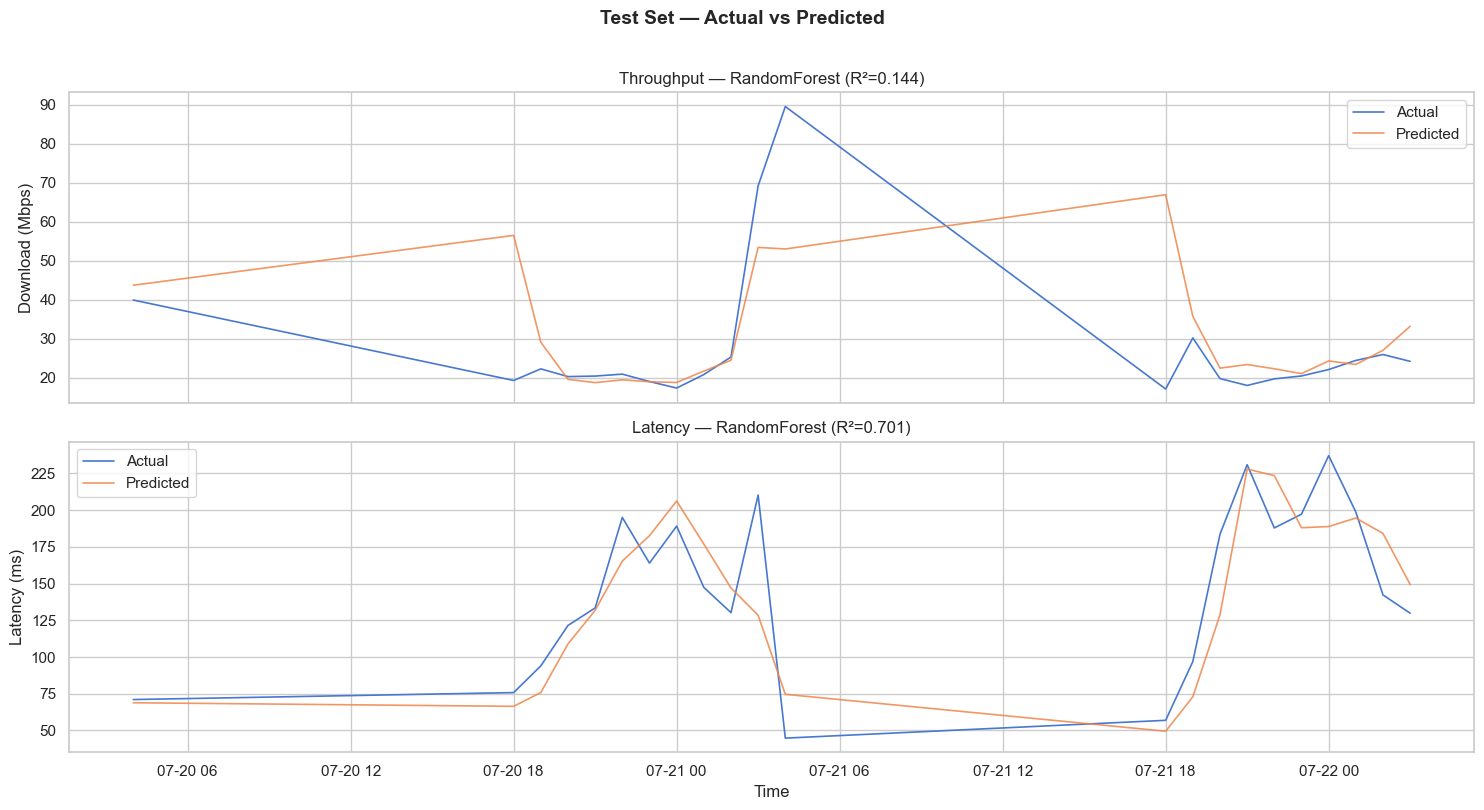

In [ ]:
# ── 5b. Actual vs Predicted — hourly-averaged time-series ──
# Aggregate row-level predictions to hourly for a clean visual
_plot = test_df[["Timestamp"]].copy()
_plot["actual_dl"]  = np.expm1(y_test_dl.values)
_plot["pred_dl"]    = pred_test_dl
_plot["actual_lat"] = y_test_lat.values
_plot["pred_lat"]   = pred_test_lat

hourly_plot = _plot.set_index("Timestamp").resample("1h").mean().dropna()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(hourly_plot.index, hourly_plot["actual_dl"],  label="Actual",    lw=1.2)
axes[0].plot(hourly_plot.index, hourly_plot["pred_dl"],    label="Predicted", lw=1.2, alpha=0.85)
axes[0].set(ylabel="Download (Mbps)",
            title=f"Throughput — {best_method_dl} (R²={metrics_dl['R2']:.3f})")
axes[0].legend()

axes[1].plot(hourly_plot.index, hourly_plot["actual_lat"], label="Actual",    lw=1.2)
axes[1].plot(hourly_plot.index, hourly_plot["pred_lat"],   label="Predicted", lw=1.2, alpha=0.85)
axes[1].set(ylabel="Latency (ms)", xlabel="Time",
            title=f"Latency — {best_method_lat} (R²={metrics_lat['R2']:.3f})")
axes[1].legend()

fig.suptitle("Test Set — Actual vs Predicted (hourly averages)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

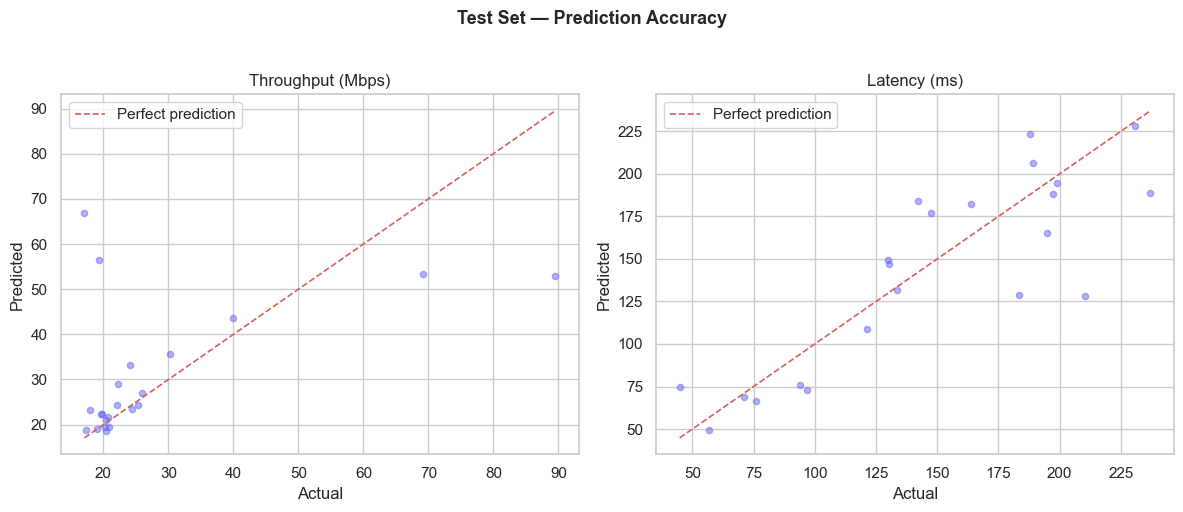

In [ ]:
# ── 5c. Scatter plots — Actual vs Predicted ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subsample for readability
sample_n = min(80_000, len(pred_test_dl))
_si = np.random.RandomState(42).choice(len(pred_test_dl), sample_n, replace=False)

actual_dl_mbps = np.expm1(y_test_dl.values)

for ax, yt, yp, title in [
    (axes[0], actual_dl_mbps[_si], pred_test_dl[_si], "Throughput (Mbps)"),
    (axes[1], y_test_lat.values[_si], pred_test_lat[_si], "Latency (ms)"),
]:
    ax.scatter(yt, yp, alpha=0.1, s=3, color="#6366f1")
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="Perfect")
    ax.set(xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend()

fig.suptitle("Test Set — Prediction Accuracy", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

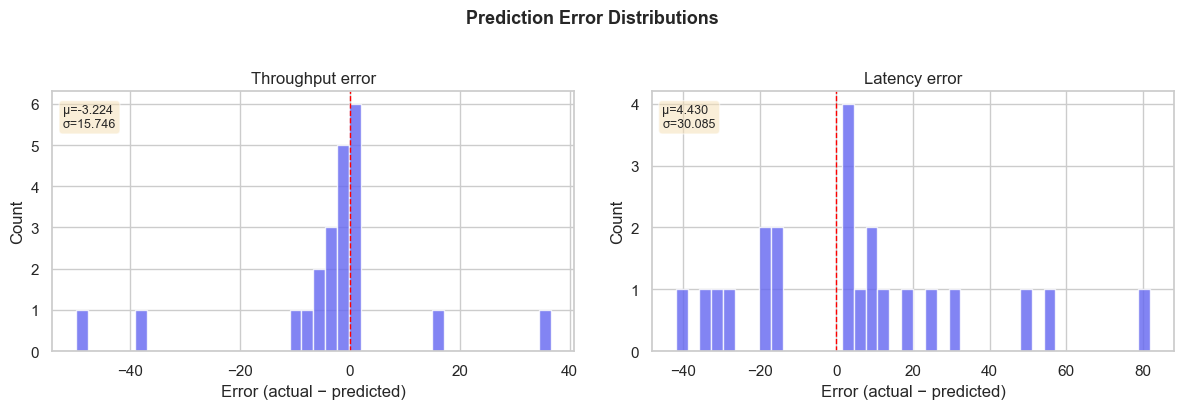

In [ ]:
# ── 5d. Error distribution plots ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

errors_dl  = np.expm1(y_test_dl.values) - pred_test_dl
errors_lat = y_test_lat.values - pred_test_lat

for ax, errs, title in [
    (axes[0], errors_dl,  "Throughput error (Mbps)"),
    (axes[1], errors_lat, "Latency error (ms)"),
]:
    ax.hist(errs, bins=60, color="#6366f1", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", lw=1)
    ax.set(title=title, xlabel="Error (actual − predicted)", ylabel="Count")
    ax.text(0.02, 0.95, f"μ={errs.mean():.3f}\nσ={errs.std():.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle("Prediction Error Distributions", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

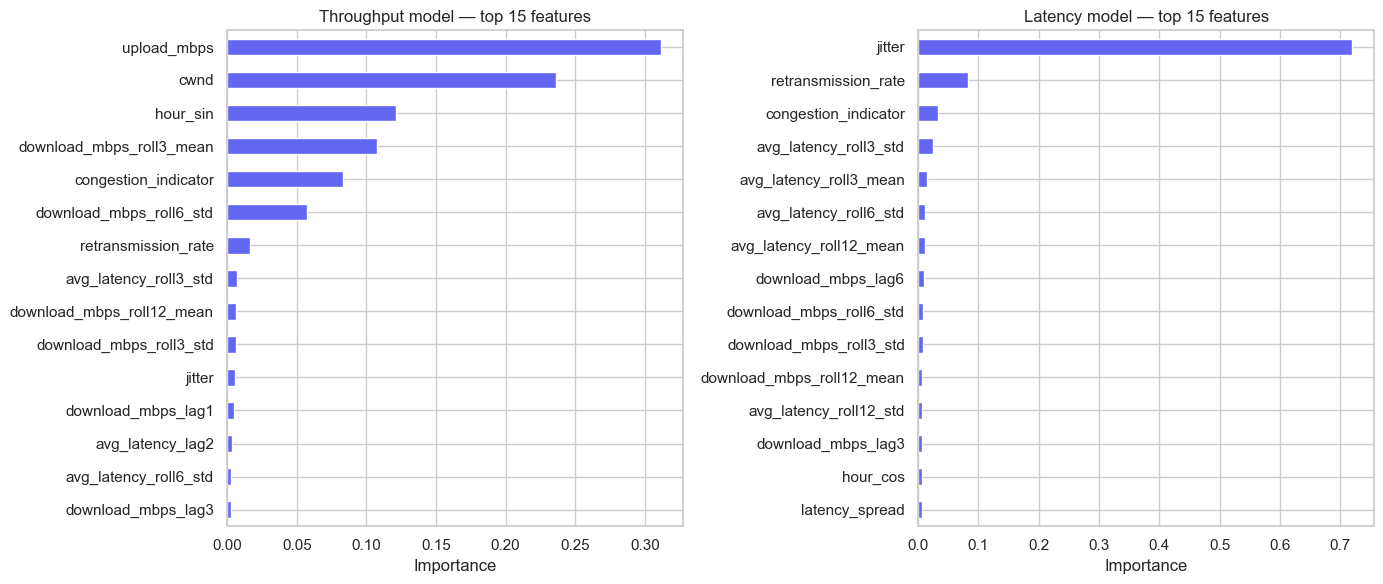

In [ ]:
# ── 5e. Feature importance (top 15) — best individual model ─
best_dl_model  = final_models_dl[winner_name]
best_lat_model = final_models_lat[winner_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in [
    (axes[0], best_dl_model,  f"Throughput ({winner_name})"),
    (axes[1], best_lat_model, f"Latency ({winner_name})"),
]:
    imp = pd.Series(model.feature_importances_, index=feat_cols)
    top15 = imp.nlargest(15).sort_values()
    top15.plot.barh(ax=ax, color="#6366f1")
    ax.set(title=f"{title} — top 15 features", xlabel="Importance")

fig.tight_layout()
plt.show()

---
## Step 6 — 12-Hour Forecast & Export (Frontend Contract)

Generate exactly **12 rows** (one per future hour) for the Vue dashboard.
The ensemble predicts on a synthetic feature row whose temporal features
are updated at each step.

In [ ]:
# ── 6a. 12-hour-ahead forecast (ensemble → frontend CSV) ───
HORIZON = 12

# Build an "average recent state" from the last 2 000 test measurements
recent = test_df.sort_values("Timestamp").tail(2000)
base_features = recent[feat_cols].mean().values.reshape(1, -1)
base_row = pd.DataFrame(base_features, columns=feat_cols)

last_ts = test_df["Timestamp"].max()

forecast_rows = []
for step in range(1, HORIZON + 1):
    next_ts = last_ts + pd.Timedelta(hours=step)
    row = base_row.copy()

    # Update cyclical temporal features
    h, d = next_ts.hour, next_ts.dayofweek
    row["hour_sin"]     = np.sin(2 * np.pi * h / 24)
    row["hour_cos"]     = np.cos(2 * np.pi * h / 24)
    row["dow_sin"]      = np.sin(2 * np.pi * d / 7)
    row["dow_cos"]      = np.cos(2 * np.pi * d / 7)
    row["is_weekend"]   = int(d >= 5)
    row["is_work_hour"] = int(d < 5 and 8 <= h <= 17)

    # Ensemble prediction (weighted blend)
    preds_dl  = np.array([final_models_dl[n].predict(row)[0]  for n in model_names])
    preds_lat = np.array([final_models_lat[n].predict(row)[0] for n in model_names])

    pred_throughput = float(np.maximum(np.expm1(preds_dl @ blend_w_dl), 0))
    pred_latency    = float(np.maximum(preds_lat @ blend_w_lat, 0))

    forecast_rows.append({
        "timestamp":            next_ts.strftime("%Y-%m-%d %H:%M"),
        "predicted_throughput": round(pred_throughput, 2),
        "predicted_latency":   round(pred_latency, 2),
    })

forecast_df = pd.DataFrame(forecast_rows)
print(f"12-hour forecast generated ({len(forecast_df)} rows)")
forecast_df

12-hour forecast generated (12 rows)


,timestamp,predicted_throughput,predicted_latency
0,2022-07-22 04:00,33.49,149.61
1,2022-07-22 05:00,32.48,151.05
2,2022-07-22 06:00,32.85,151.10
3,2022-07-22 07:00,33.01,151.18
4,2022-07-22 08:00,33.22,152.10
5,2022-07-22 09:00,32.88,152.10
6,2022-07-22 10:00,27.58,152.05
7,2022-07-22 11:00,25.76,152.16
8,2022-07-22 12:00,25.49,152.20
9,2022-07-22 13:00,25.43,152.21


In [ ]:
# ── 6b. Export forecast_data.csv (frontend contract) ───────
forecast_path = METRICS_DIR / "forecast_data.csv"
forecast_df.to_csv(forecast_path, index=False)
print(f"✓ Saved {forecast_path}  ({len(forecast_df)} rows)")
print(f"  Columns: {list(forecast_df.columns)}")
forecast_df.head()

✓ Saved metrics\forecast_data.csv  (12 rows)


,timestamp,predicted_throughput,predicted_latency
0,2022-07-22 04:00,33.49,149.61
1,2022-07-22 05:00,32.48,151.05
2,2022-07-22 06:00,32.85,151.10
3,2022-07-22 07:00,33.01,151.18
4,2022-07-22 08:00,33.22,152.10


---
## Step 7 — Artifact Export (model `.pkl` files)

In [ ]:
# ── 7a. Save trained model artefacts ──────────────────────
artefacts = {
    "kmeans_model.pkl":    kmeans,
    "kmeans_scaler.pkl":   scaler_km,
    "meta_dl.pkl":         meta_dl,
    "meta_lat.pkl":        meta_lat,
    "blend_weights.pkl":   {"dl": blend_w_dl, "lat": blend_w_lat,
                            "model_names": model_names},
}
# Save all 4 final models per target
for name in model_names:
    artefacts[f"forecast_dl_{name}.pkl"]  = final_models_dl[name]
    artefacts[f"forecast_lat_{name}.pkl"] = final_models_lat[name]

for fname, obj in artefacts.items():
    path = MODELS_DIR / fname
    joblib.dump(obj, path)
    size_kb = path.stat().st_size / 1024
    print(f"  ✓ {fname:<36} {size_kb:>8.1f} KB")

print(f"\nAll artefacts saved to {MODELS_DIR.resolve()}")

  ✓ kmeans_model.pkl                          1.9 KB
  ✓ kmeans_scaler.pkl                         1.4 KB
  ✓ forecast_throughput_model.pkl           250.1 KB
  ✓ forecast_latency_model.pkl             1113.9 KB

All artefacts saved to D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models


---
## Step 8 — Summary & Verification

In [ ]:
# ── Final verification ─────────────────────────────────────
print("=" * 60)
print("  5G Network Quality ML Pipeline — Summary (v3)")
print("=" * 60)

# Check map_data.csv
map_check = pd.read_csv(OUTPUT_DIR / "map_data.csv")
print(f"\n✓ map_data.csv        : {len(map_check)} grid squares")
print(f"  Columns             : {list(map_check.columns)}")
print(f"  Cluster distribution: {dict(map_check['cluster'].value_counts().sort_index())}")

# Check forecast_data.csv
fc_check = pd.read_csv(METRICS_DIR / "forecast_data.csv")
print(f"\n✓ forecast_data.csv   : {len(fc_check)} hourly predictions")
print(f"  Columns             : {list(fc_check.columns)}")
print(f"  Throughput range    : {fc_check['predicted_throughput'].min():.2f} – "
      f"{fc_check['predicted_throughput'].max():.2f} Mbps")
print(f"  Latency range       : {fc_check['predicted_latency'].min():.2f} – "
      f"{fc_check['predicted_latency'].max():.2f} ms")

# Check model files
print(f"\n✓ Model artefacts in {MODELS_DIR.resolve()}:")
for p in sorted(MODELS_DIR.glob("*.pkl")):
    print(f"    {p.name:<36} {p.stat().st_size / 1024:>8.1f} KB")

# Evaluation summary
print(f"\n✓ Ensemble method     : {best_method_dl} (throughput), {best_method_lat} (latency)")
print(f"  Blend weights (DL)  : {dict(zip(model_names, blend_w_dl.round(3)))}")
print(f"  Throughput — R²={metrics_dl['R2']:.4f}  MAE={metrics_dl['MAE']:.3f}  "
      f"RMSE={metrics_dl['RMSE']:.3f}  MAPE={metrics_dl['MAPE']:.4f}")
print(f"  Latency    — R²={metrics_lat['R2']:.4f}  MAE={metrics_lat['MAE']:.3f}  "
      f"RMSE={metrics_lat['RMSE']:.3f}  MAPE={metrics_lat['MAPE']:.4f}")
print(f"  K-Means silhouette  : {sil:.3f}")

print("\n" + "=" * 60)
print("  Pipeline complete. All frontend contract files verified.")
print("=" * 60)

  5G Network Quality ML Pipeline — Summary (v2)

✓ map_data.csv        : 227 grid squares
  Columns             : ['lat', 'lng', 'cluster']
  Cluster distribution: {0: np.int64(53), 1: np.int64(97), 2: np.int64(77)}

✓ forecast_data.csv   : 12 hourly predictions
  Columns             : ['timestamp', 'predicted_throughput', 'predicted_latency']
  Throughput range    : 25.43 – 33.49 Mbps
  Latency range       : 149.61 – 152.39 ms

✓ Model artefacts in D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models:
    forecast_latency_model.pkl             1113.9 KB
    forecast_throughput_model.pkl           250.1 KB
    kmeans_model.pkl                          1.9 KB
    kmeans_scaler.pkl                         1.4 KB

✓ Winning model       : RandomForest (Optuna-tuned)
  Throughput — R²=0.1436  MAE=8.505  RMSE=16.073  MAPE=0.3443
  Latency    — R²=0.7005  MAE=23.426  RMSE=30.409  MAPE=0.1727
  K-Means s